In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
data = pd.read_excel('../data/processed/cleaned_disaster_dataset.xlsx')
data.head()

,disaster_type,magnitude,start_month,event_duration_log,magnitude_missing,subregion_Australia and New Zealand,subregion_Central Asia,subregion_Eastern Asia,subregion_Eastern Europe,subregion_Latin America and the Caribbean,...,subregion_Southern Europe,subregion_Sub-Saharan Africa,subregion_Western Asia,subregion_Western Europe,magnitude_scale_Km2,magnitude_scale_Kph,magnitude_scale_Moment Magnitude,magnitude_scale_Unknown,magnitude_scale_Vaccinated,magnitude_scale_°C
0,Storm,220.0,9,0.0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,Flood,0.0,1,0.0,1,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
2,Epidemic,0.0,1,0.0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
3,Volcanic activity,0.0,7,0.0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
4,Earthquake,5.9,7,0.0,0,0,0,0,0,0,...,0,0,1,0,0,0,1,0,0,0


In [5]:
X = data.drop("disaster_type", axis=1)
y = data["disaster_type"]

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (14204, 27)
Test size: (3552, 27)


In [8]:

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    max_depth=15, 
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [9]:
y_pred_rf = rf.predict(X_test)

In [10]:
from sklearn.metrics import classification_report, accuracy_score

print("RandomForest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

RandomForest Accuracy: 0.8885135135135135
                     precision    recall  f1-score   support

            Drought       0.60      0.74      0.66       167
         Earthquake       1.00      1.00      1.00       315
           Epidemic       0.92      0.88      0.90       322
Extreme temperature       1.00      0.99      1.00       141
              Flood       0.94      0.87      0.90      1279
          Landslide       0.72      0.60      0.65       194
              Storm       1.00      1.00      1.00       979
  Volcanic activity       0.34      0.66      0.45        56
           Wildfire       0.34      0.51      0.41        99

           accuracy                           0.89      3552
          macro avg       0.76      0.80      0.77      3552
       weighted avg       0.91      0.89      0.90      3552



In [11]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf, X_train, y_train, cv=5)

print("Cross-validation scores:", cv_scores)
print("Mean CV score:", cv_scores.mean())

Cross-validation scores: [0.88877156 0.8873636  0.88912355 0.89581133 0.89401408]
Mean CV score: 0.8910168260531156


In [12]:

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))

RF Accuracy: 0.8885135135135135


In [13]:
print(sorted(y.unique()))

['Drought', 'Earthquake', 'Epidemic', 'Extreme temperature', 'Flood', 'Landslide', 'Storm', 'Volcanic activity', 'Wildfire']


In [14]:
class_names = sorted(y.unique())

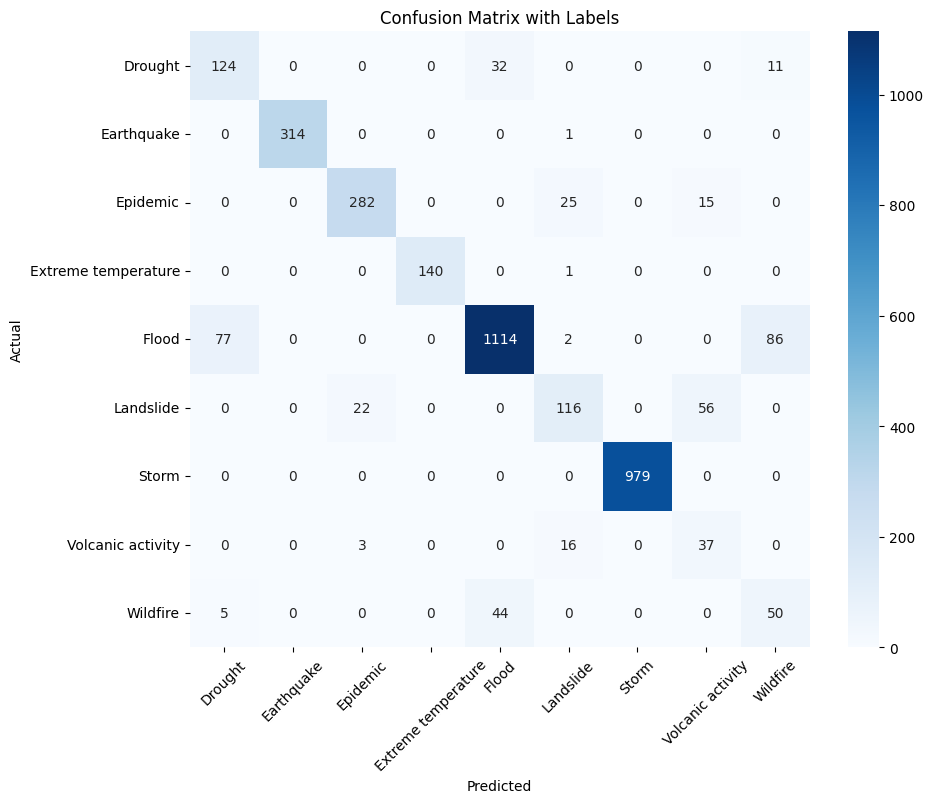

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix with Labels")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

Some classes are getting confused with similar classes

Why this happen? ==> Some disaster types have similar features
The confusion matrix shows that the model performs well for several disaster types, particularly for classes with strong diagonal values such as class 4 and class 6. However, some misclassification occurs between similar classes, indicating overlapping feature characteristics. This suggests that certain disaster types share similar patterns, making them harder to distinguish.

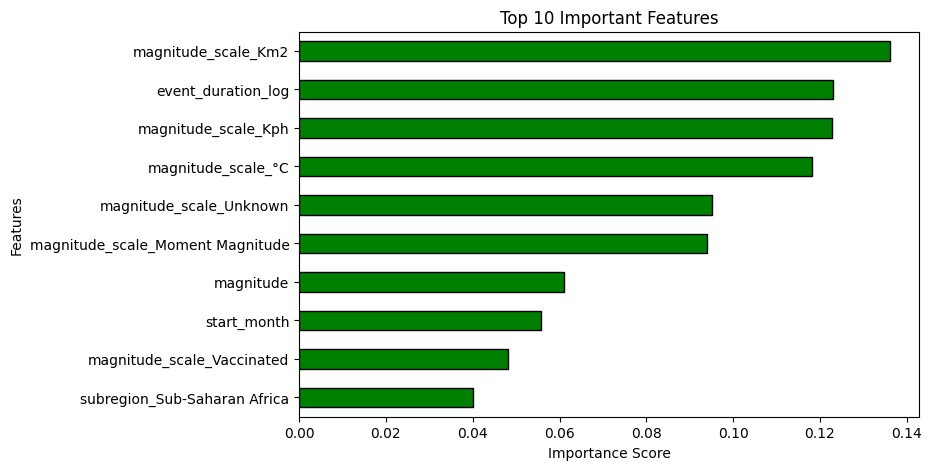

In [16]:
#Features importance
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

top_features = importance.head(10)

plt.figure(figsize=(8,5))

top_features.plot(
    kind="barh",
    color="green",       
    edgecolor="black"
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.gca().invert_yaxis() 

plt.show()

In [17]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

In [39]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax", # multi-class classification
    num_class=9,                # 9 disaster types
    random_state=42,
)

xgb.fit(X_train, y_train_encoded)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=

In [40]:
y_pred = xgb.predict(X_test)

In [41]:
# decode prediction back
y_pred_labels = le.inverse_transform(y_pred)

In [42]:
print("Accuracy:", accuracy_score(y_test, y_pred_labels))
print(classification_report(y_test, y_pred_labels))

Accuracy: 0.9192004504504504
                     precision    recall  f1-score   support

            Drought       0.86      0.59      0.70       167
         Earthquake       1.00      1.00      1.00       315
           Epidemic       0.92      0.89      0.90       322
Extreme temperature       1.00      0.99      1.00       141
              Flood       0.91      0.98      0.94      1279
          Landslide       0.66      0.77      0.71       194
              Storm       1.00      1.00      1.00       979
  Volcanic activity       0.36      0.25      0.29        56
           Wildfire       0.67      0.36      0.47        99

           accuracy                           0.92      3552
          macro avg       0.82      0.76      0.78      3552
       weighted avg       0.92      0.92      0.91      3552



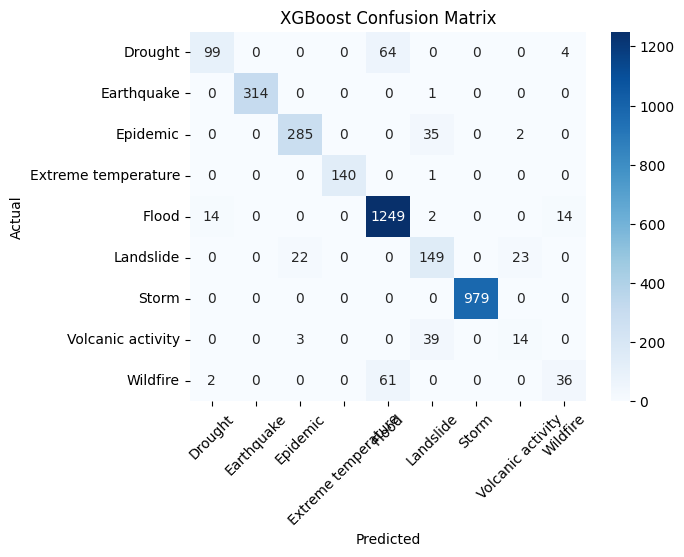

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_labels)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")

plt.xticks(rotation=45)
plt.show()